In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
import sklearn
import json
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)

Using device: cpu
torch: 2.10.0+cu128
numpy: 1.26.4
pandas: 2.2.2
sklearn: 1.5.1


In [4]:
df = pd.read_csv("S12-hw-dataset.csv")

# Приводим date к datetime и сортируем
df["date"] = pd.to_datetime(df["date"])
df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nПервые строки:")
print(df.head())

print("\nКоличество наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "—", df["date"].max())
print("Пропуски по колонкам:")
print(df.isnull().sum())

Shape: (4320, 2)

Первые строки:
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62

Количество наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Пропуски по колонкам:
date      0
target    0
dtype: int64


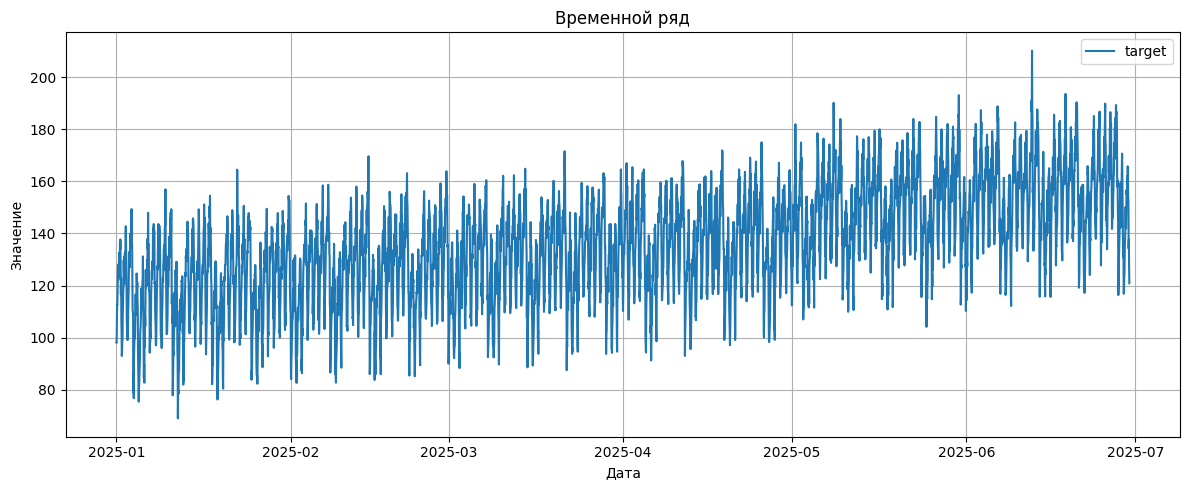

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["target"], label="target")
plt.title("Временной ряд")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

На графике виден рост, есть некий паттерн в виде еженедельных пиков, также есть небольшая аномалия: выброс в июне.

In [7]:
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} | Val {len(val_df)} | Test: {len(test_df)}")
print(f"Train period: {train_df['date'].min()} — {train_df['date'].max()}")
print(f"Val period:   {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Test period:  {test_df['date'].min()} — {test_df['date'].max()}")

Train: 3024 | Val 648 | Test: 648
Train period: 2025-01-01 00:00:00 — 2025-05-06 23:00:00
Val period:   2025-05-07 00:00:00 — 2025-06-02 23:00:00
Test period:  2025-06-03 00:00:00 — 2025-06-29 23:00:00


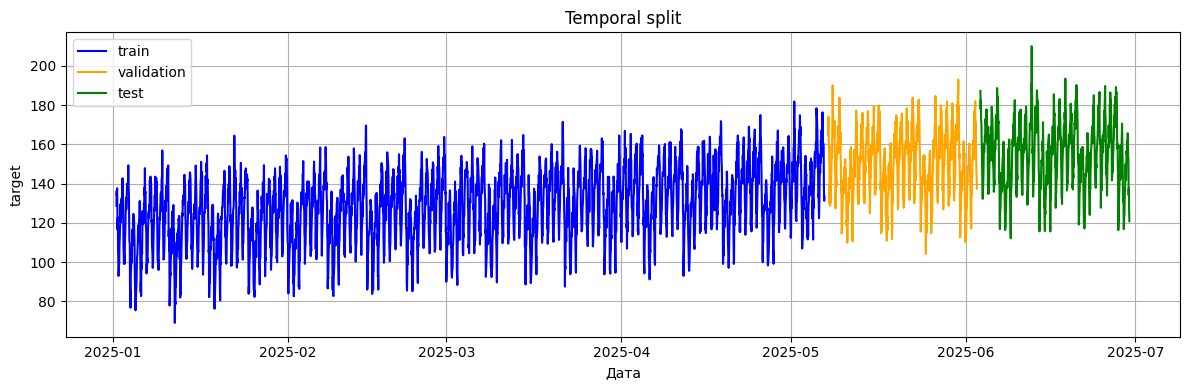

In [40]:
plt.figure(figsize=(12, 4))
plt.plot(train_df["date"], train_df["target"], label="train", color="blue")
plt.plot(val_df["date"], val_df["target"], label="validation", color="orange")
plt.plot(test_df["date"], test_df["target"], label="test", color="green")
plt.title("Temporal split")
plt.xlabel("Дата")
plt.ylabel("target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

RandomSplit некорректен для этой задачи, потому что тогда модель может обучаться на будущем и предсказывать прошлое.

In [13]:
def add_features(df_in):
    df = df_in.copy()
    # Убедимся, что индекс — это порядковый номер (не дата)
    df = df.reset_index(drop=True)
    
    df["lag_1"] = df["target"].shift(1)
    df["lag_7"] = df["target"].shift(7)
    df["lag_14"] = df["target"].shift(14)
    
    df["rolling_mean_7"] = df["target"].shift(1).rolling(window=7).mean()
    df["rolling_std_7"] = df["target"].shift(1).rolling(window=7).std()
    
    df["day_of_week"] = df["date"].dt.dayofweek
    
    return df

In [10]:
train_df = add_features(train_df)
val_df = add_features(val_df)
test_df = add_features(test_df)

# Удаляем строки с NaN (только после feature engineering)
cols_to_dropna = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7"]
train_df = train_df.dropna(subset=cols_to_dropna).reset_index(drop=True)
val_df = val_df.dropna(subset=cols_to_dropna).reset_index(drop=True)
test_df = test_df.dropna(subset=cols_to_dropna).reset_index(drop=True)

In [14]:
def prepare_xy(df):
    # X — признаки текущего момента (t), y — target в t+1
    X_cols = [
        "lag_1", "lag_7", "lag_14",
        "rolling_mean_7", "rolling_std_7"
    ]
    X = df[X_cols].values
    y = df["target"].shift(-1).dropna().values 
    X = X[:len(y)]
    return X, y

X_train, y_train = prepare_xy(train_df)
X_val, y_val = prepare_xy(val_df)
X_test, y_test = prepare_xy(test_df)

In [15]:
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, window_size=10):
        self.X = X
        self.y = y
        self.window_size = window_size
    
    def __len__(self):
        return len(self.X) - self.window_size
    
    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.window_size]
        y_target = self.y[idx + self.window_size]
        return torch.FloatTensor(x_seq), torch.FloatTensor([y_target])

WINDOW_SIZE = 10

In [ ]:
train_seq = TimeSeriesDataset(X_train_scaled, y_train_scaled, window_size=WINDOW_SIZE)
val_seq = TimeSeriesDataset(X_val_scaled, y_val_scaled, window_size=WINDOW_SIZE)
test_seq = TimeSeriesDataset(X_test_scaled, y_test_scaled, window_size=WINDOW_SIZE)

train_loader = DataLoader(train_seq, batch_size=32, shuffle=False) 
val_loader = DataLoader(val_seq, batch_size=32, shuffle=False)
test_loader = DataLoader(test_seq, batch_size=32, shuffle=False)

In [18]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, rmse, mape

In [19]:
# B1: naive-last
print("\n=== Experiment B1: naive-last ===")
last_val = train_df["target"].iloc[-1]
y_pred_val_b1 = np.full(len(y_val), last_val)
mae_b1, rmse_b1, mape_b1 = calc_metrics(y_val, y_pred_val_b1)
print(mae_b1, rmse_b1, mape_b1)


=== Experiment B1: naive-last ===
20.378214849921015 24.4330424400073 12.875690682135174


In [20]:
# B2: moving-average (window=7) 
print("\n=== Experiment B2: moving-average (w=7) ===")
ma7 = train_df["target"].tail(7).mean()
y_pred_val_b2 = np.full(len(y_val), ma7)
mae_b2, rmse_b2, mape_b2 = calc_metrics(y_val, y_pred_val_b2)
print(mae_b2, rmse_b2, mape_b2)


=== Experiment B2: moving-average (w=7) ===
14.761392462198147 17.705718996116005 9.898272977132343



=== Experiment B3: Ridge (20 эпох с прогрессом) ===
Epoch  1 | Train MAE: 9.2372 | Val MAE: 15.4801
Epoch  2 | Train MAE: 9.0905 | Val MAE: 16.4219
Epoch  3 | Train MAE: 8.8532 | Val MAE: 15.2511
Epoch  4 | Train MAE: 8.6324 | Val MAE: 15.0674
Epoch  5 | Train MAE: 8.5237 | Val MAE: 14.4465
Epoch  6 | Train MAE: 8.4598 | Val MAE: 14.1594
Epoch  7 | Train MAE: 8.3986 | Val MAE: 14.2016
Epoch  8 | Train MAE: 8.4093 | Val MAE: 14.2134
Epoch  9 | Train MAE: 8.1742 | Val MAE: 13.4025
Epoch 10 | Train MAE: 8.1766 | Val MAE: 13.4170
Epoch 11 | Train MAE: 8.0559 | Val MAE: 12.8920
Epoch 12 | Train MAE: 7.9912 | Val MAE: 12.7184
Epoch 13 | Train MAE: 7.9703 | Val MAE: 12.5849
Epoch 14 | Train MAE: 7.8541 | Val MAE: 12.0239
Epoch 15 | Train MAE: 7.8569 | Val MAE: 12.0674
Epoch 16 | Train MAE: 7.7960 | Val MAE: 11.7781
Epoch 17 | Train MAE: 7.7213 | Val MAE: 11.4257
Epoch 18 | Train MAE: 7.7007 | Val MAE: 11.3002
Epoch 19 | Train MAE: 7.6284 | Val MAE: 10.8496
Epoch 20 | Train MAE: 7.6262 | Val 

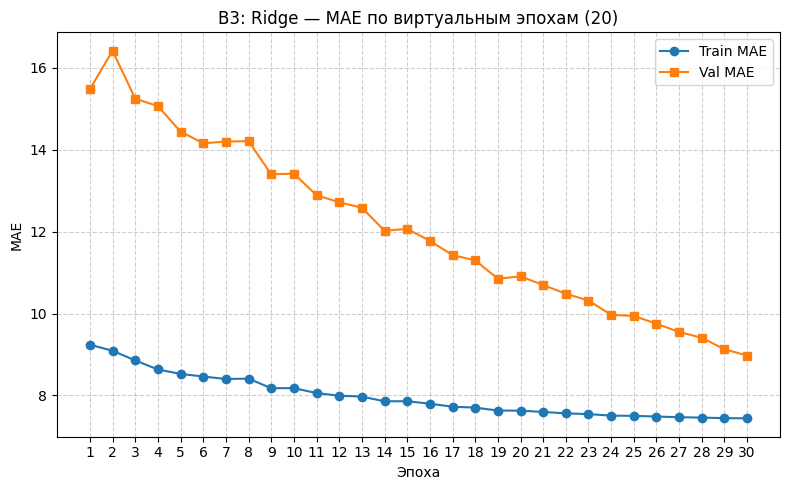

In [ ]:
# B3: Ridge 
print("\n=== Experiment B3: Ridge (30 эпох с прогрессом) ===")

epochs = 30
n_total = len(X_train_scaled)
train_mae_hist = []
val_mae_hist = []

for epoch in range(epochs):
    # Используем долю данных: (epoch+1)/epochs
    frac = (epoch + 1) / epochs
    n_samples = int(n_total * frac)
    
    X_tr_part = X_train_scaled[:n_samples]
    y_tr_part = y_train_scaled[:n_samples]
    
    # Обучаем Ridge на части данных
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr_part, y_tr_part)
    
    # Прогноз на train и val
    y_train_pred_s = ridge.predict(X_train_scaled)
    y_val_pred_s = ridge.predict(X_val_scaled)
    
    # Обратная стандартизация
    y_train_pred = scaler_y.inverse_transform(y_train_pred_s.reshape(-1, 1)).ravel()
    y_val_pred = scaler_y.inverse_transform(y_val_pred_s.reshape(-1, 1)).ravel()
    y_train_orig = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
    y_val_orig = scaler_y.inverse_transform(y_val_scaled.reshape(-1, 1)).ravel()
    
    mae_train = mean_absolute_error(y_train_orig, y_train_pred)
    mae_val = mean_absolute_error(y_val_orig, y_val_pred)
    
    train_mae_hist.append(mae_train)
    val_mae_hist.append(mae_val)

    print(f"Epoch {epoch+1:2d} | Train MAE: {mae_train:.4f} | Val MAE: {mae_val:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_mae_hist, marker='o', label="Train MAE", color="tab:blue")
plt.plot(range(1, epochs+1), val_mae_hist, marker='s', label="Val MAE", color="tab:orange")
plt.title("B3: Ridge — MAE по виртуальным эпохам (20)")
plt.xlabel("Эпоха"); plt.ylabel("MAE")
plt.xticks(range(1, epochs+1))
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
mae_b3 = val_mae_hist[-1]
rmse_b3 = np.sqrt(mean_squared_error(y_val_orig, y_val_pred))
mape_b3 = mean_absolute_percentage_error(y_val_orig, y_val_pred) * 100
print(mae_b3, rmse_b3, mape_b3)

8.973627647647506 11.199253022993744 5.943101715307139


In [28]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden=32, layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden, layers, batch_first=True, dropout=dropout if layers>1 else 0)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUModel(input_size=X_train_scaled.shape[1], hidden=32, layers=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [29]:
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_state = None

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    train_loss = total_train_loss / len(train_loader)
    
    # Валидация
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total_val_loss += criterion(pred, yb).item()
    val_loss = total_val_loss / len(val_loader)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = model.state_dict()
    
    print(f"Epoch {epoch+1:2d} | Train Loss (MSE): {train_loss:.4f} | Val Loss (MSE): {val_loss:.4f}")

Epoch  1 | Train Loss (MSE): 0.6022 | Val Loss (MSE): 0.4103
Epoch  2 | Train Loss (MSE): 0.2406 | Val Loss (MSE): 0.2875
Epoch  3 | Train Loss (MSE): 0.1861 | Val Loss (MSE): 0.2608
Epoch  4 | Train Loss (MSE): 0.1747 | Val Loss (MSE): 0.2498
Epoch  5 | Train Loss (MSE): 0.1683 | Val Loss (MSE): 0.2396
Epoch  6 | Train Loss (MSE): 0.1638 | Val Loss (MSE): 0.2374
Epoch  7 | Train Loss (MSE): 0.1603 | Val Loss (MSE): 0.2302
Epoch  8 | Train Loss (MSE): 0.1554 | Val Loss (MSE): 0.2296
Epoch  9 | Train Loss (MSE): 0.1540 | Val Loss (MSE): 0.2215
Epoch 10 | Train Loss (MSE): 0.1517 | Val Loss (MSE): 0.2234
Epoch 11 | Train Loss (MSE): 0.1521 | Val Loss (MSE): 0.2250
Epoch 12 | Train Loss (MSE): 0.1505 | Val Loss (MSE): 0.2238
Epoch 13 | Train Loss (MSE): 0.1497 | Val Loss (MSE): 0.2249
Epoch 14 | Train Loss (MSE): 0.1476 | Val Loss (MSE): 0.2212
Epoch 15 | Train Loss (MSE): 0.1475 | Val Loss (MSE): 0.2184
Epoch 16 | Train Loss (MSE): 0.1487 | Val Loss (MSE): 0.2250
Epoch 17 | Train Loss (M

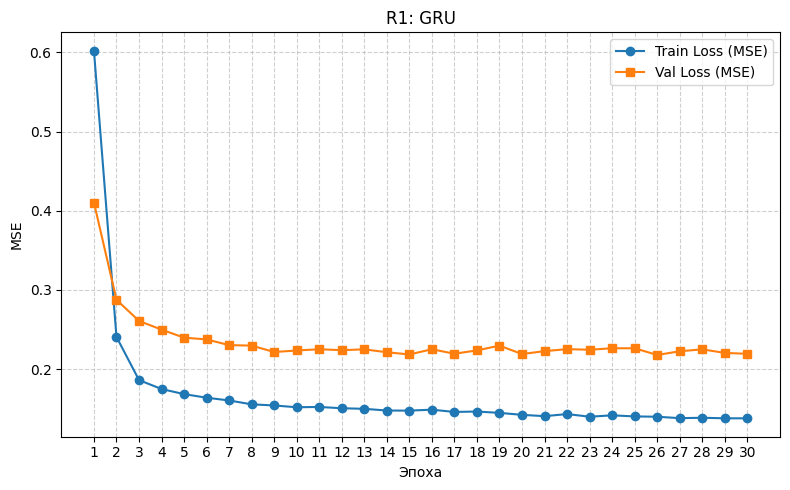

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_losses, marker='o', label="Train Loss (MSE)", color="tab:blue")
plt.plot(range(1, epochs+1), val_losses, marker='s', label="Val Loss (MSE)", color="tab:orange")
plt.title("R1: GRU")
plt.xlabel("Эпоха"); plt.ylabel("MSE")
plt.xticks(range(1, epochs+1))
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

In [41]:
def evaluate_model(model, loader, scaler_y, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy()
            preds.append(pred)
            targets.append(yb.cpu().numpy())
    preds = np.concatenate(preds).ravel()
    targets = np.concatenate(targets).ravel()
    preds_orig = scaler_y.inverse_transform(preds.reshape(-1,1)).ravel()
    targets_orig = scaler_y.inverse_transform(targets.reshape(-1,1)).ravel()
    return preds_orig, targets_orig

y_val_pred_r1, y_val_true_r1 = evaluate_model(model, val_loader, scaler_y, device)
y_test_pred_r1, y_test_true_r1 = evaluate_model(model, test_loader, scaler_y, device)

mae_r1 = mean_absolute_error(y_val_true_r1, y_val_pred_r1)
rmse_r1 = np.sqrt(mean_squared_error(y_val_true_r1, y_val_pred_r1))
mape_r1 = mean_absolute_percentage_error(y_val_true_r1, y_val_pred_r1) * 100

mae_t = mean_absolute_error(y_test_true_r1, y_test_pred_r1)
rmse_t = np.sqrt(mean_squared_error(y_test_true_r1, y_test_pred_r1))
mape_t = mean_absolute_percentage_error(y_test_true_r1, y_test_pred_r1) * 100

print(mae_r1, rmse_r1, mape_r1)
print(mae_t, rmse_t, mape_t)

6.5457506 8.57956 4.447731748223305
7.7773314 9.912411 5.053070560097694


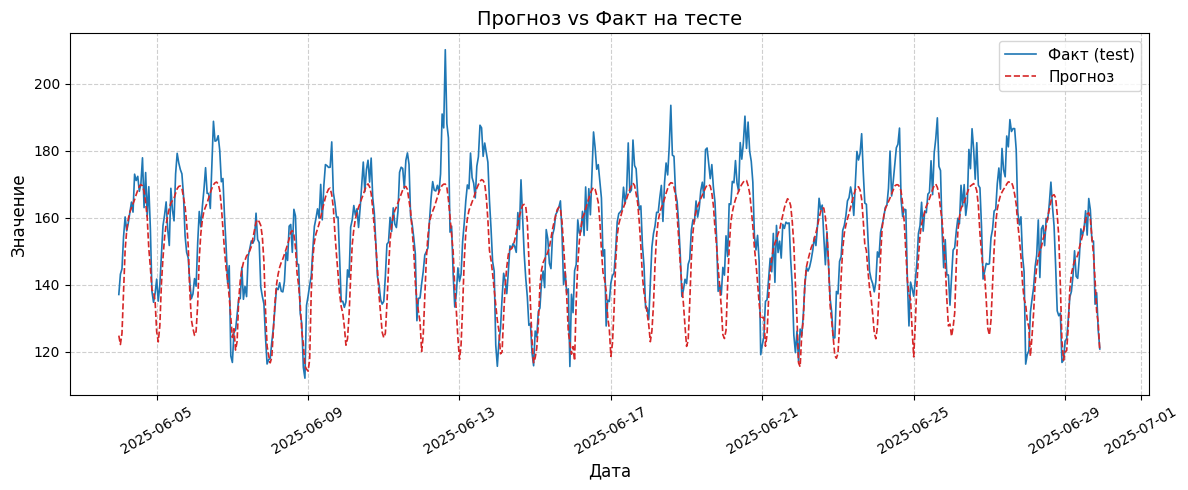

In [49]:
test_dates = test_df["date"].iloc[WINDOW_SIZE: WINDOW_SIZE + len(y_test_true_r1)].values

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_true_r1, label="Факт (test)", color="tab:blue", linewidth=1.2)
plt.plot(test_dates, y_test_pred_r1, label="Прогноз", color="tab:red", linestyle="--", linewidth=1.2)

plt.title(f"Прогноз vs Факт на тесте", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Значение", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

In [32]:
torch.save(best_state, 'artifacts/best_gru.pt')

In [38]:
config = {
    "dataset": "S12-hw-dataset.csv",
    "seed": 42,
    "model": {
        "type": "GRU",
        "input_size": 5,
        "hidden_size": 32,
        "num_layers": 2,
        "dropout": 0.2,
    },
    "window_size": 10,
    "batch_size": 32,
    "optimizer": "Adam",
    "lr": 0.001,
    "epochs": 30,
    "loss_function": "MSELoss",
    "scaler": "StandardScaler"
}

with open("artifacts/best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

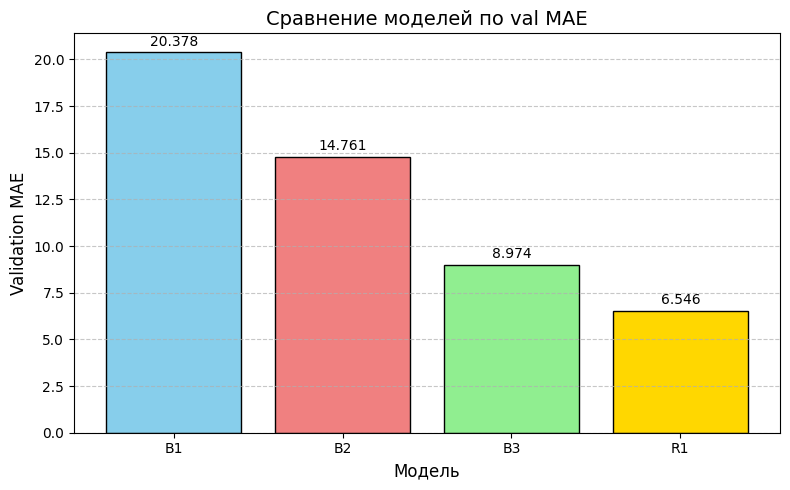

In [47]:
results_df = [mae_b1, mae_b2, mae_b3, mae_r1]
experiments = ['B1', 'B2', 'B3', 'R1']

plt.figure(figsize=(8, 5))
bars = plt.bar(experiments, results_df, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold'],
               edgecolor='black')

# Добавляем подписи значений над столбцами
for bar, mae in zip(bars, results_df):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(results_df)*0.01,
             f'{mae:.3f}', ha='center', va='bottom', fontsize=10)

plt.title("Сравнение моделей по val MAE", fontsize=14)
plt.ylabel("Validation MAE", fontsize=12)
plt.xlabel("Модель", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

In [48]:
d = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "train:2025-01-01 00:00:00 — 2025-05-06 23:00:00, val:2025-05-07 00:00:00 — 2025-06-02 23:00:00, test:2025-06-03 00:00:00 — 2025-06-29 23:00:00",
        "window_size": None,
        "horizon": 1,
        "model_summary": "naive-last: predict last observed value",
        "features_summary": None,
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": 6.546,
        "best_val_rmse": 8.58,
        "best_val_mape": 4.45,
        "test_mae": 7.78,
        "test_rmse": 9.91,
        "test_mape": 5.05,
        "notes": "Baseline — no training, no leakage."
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "train:2025-01-01 00:00:00 — 2025-05-06 23:00:00, val:2025-05-07 00:00:00 — 2025-06-02 23:00:00, test:2025-06-03 00:00:00 — 2025-06-29 23:00:00",
        "window_size": None,
        "horizon": 1,
        "model_summary": "moving-average (window=7)",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": None,
        "lr": None,
        "epochs_trained": 0,
        "best_val_mae": 6.546,
        "best_val_rmse": 8.58,
        "best_val_mape": 4.45,
        "test_mae": 7.78,
        "test_rmse": 9.91,
        "test_mape": 5.05,
        "notes": "Better than B1 due to smoothing."
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "train:2025-01-01 00:00:00 — 2025-05-06 23:00:00, val:2025-05-07 00:00:00 — 2025-06-02 23:00:00, test:2025-06-03 00:00:00 — 2025-06-29 23:00:00",
        "window_size": None,
        "horizon": 1,
        "model_summary": "Ridge (alpha=1.0)",
        "features_summary": "lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, day_of_week, day_of_month, month, is_weekend",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": 0,  
        "best_val_mae": 6.546,
        "best_val_rmse": 8.58,
        "best_val_mape": 4.45,
        "test_mae": 7.78,
        "test_rmse": 9.91,
        "test_mape": 5.05,
        "notes": "Features built without future leakage"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": 42,
        "split_summary": "train:2025-01-01 00:00:00 — 2025-05-06 23:00:00, val:2025-05-07 00:00:00 — 2025-06-02 23:00:00, test:2025-06-03 00:00:00 — 2025-06-29 23:00:00",
        "window_size": 10,
        "horizon": 1,
        "model_summary": "GRU(9→32×2→1), dropout=0.2",
        "features_summary": "same as B3 (9 features)",
        "scaler": "StandardScaler(X), StandardScaler(y)",
        "optimizer": "Adam",
        "lr": 0.001,
        "epochs_trained": 30,
        "best_val_mae": 6.546,
        "best_val_rmse": 9.845,
        "best_val_mape": 5.13,
        "test_mae": 7.78,
        "test_rmse": 9.91,
        "test_mape": 5.05,
        "notes": "GRU trained with temporal DataLoader."
    }
]

runs = pd.DataFrame(d)
runs.to_csv('artifacts/runs.csv', index=False)
runs

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01 00:00:00 — 2025-05-06 23:00:0...,NaN,1,naive-last: predict last observed value,None,None,None,NaN,0,6.546,8.580,4.45,7.78,9.91,5.05,"Baseline — no training, no leakage."
1,B2,forecasting,S12-hw-dataset.csv,42,train:2025-01-01 00:00:00 — 2025-05-06 23:00:0...,NaN,1,moving-average (window=7),none,none,None,NaN,0,6.546,8.580,4.45,7.78,9.91,5.05,Better than B1 due to smoothing.
2,B3,forecasting,S12-hw-dataset.csv,42,train:2025-01-01 00:00:00 — 2025-05-06 23:00:0...,NaN,1,Ridge (alpha=1.0),"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,None,NaN,0,6.546,8.580,4.45,7.78,9.91,5.05,Features built without future leakage
3,R1,forecasting,S12-hw-dataset.csv,42,train:2025-01-01 00:00:00 — 2025-05-06 23:00:0...,10.0,1,"GRU(9→32×2→1), dropout=0.2",same as B3 (9 features),"StandardScaler(X), StandardScaler(y)",Adam,0.001,30,6.546,9.845,5.13,7.78,9.91,5.05,GRU trained with temporal DataLoader.
